<a href="https://colab.research.google.com/github/hwsinha/Brain-Tumour-Detector/blob/main/segmentation/unet_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Setup Kaggle & Download BraTS Dataset

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hwsinha","key":"9eaf6bdf0194da6a4d8e4d87accf2aa1"}'}

In [ ]:
!pip install -U kaggle -q
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d dschettler8845/brats-2021-task1
!unzip -q brats-2021-task1.zip -d /content/drive/MyDrive/brats-data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.9 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
100% 12.3G/12.3G [01:58<00:00, 111MB/s]



# Extract Dataset

In [8]:
!pip install nibabel -q
import os

data_root = '/content/drive/MyDrive/brats-data'
print(os.listdir(data_root)[:5])

['BraTS2021_00495.tar', 'BraTS2021_00621.tar', 'BraTS2021_Training_Data.tar', 'extracted']


In [ ]:
import tarfile
import os

data_root = '/content/drive/MyDrive/brats-data'
extract_path = '/content/drive/MyDrive/brats-data/extracted'
os.makedirs(extract_path, exist_ok=True)

# Extract the main training data archive
with tarfile.open(os.path.join(data_root, 'BraTS2021_Training_Data.tar')) as tar:
    tar.extractall(path=extract_path)

print(os.listdir(extract_path)[:5])

# Imports Libraries and Tools

In [5]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Data Visualization

In [10]:
all_entries = os.listdir(extract_path)
patient_folders = [f for f in all_entries if os.path.isdir(os.path.join(extract_path, f)) and not f.startswith('.')]
print(f"Found {len(patient_folders)} patient folders")
print(patient_folders[:5])

sample_patient = patient_folders[0]
patient_path = os.path.join(extract_path, sample_patient)
print(os.listdir(patient_path))
#tally patient folders and info

Found 1251 patient folders
['BraTS2021_01357', 'BraTS2021_01347', 'BraTS2021_01356', 'BraTS2021_01361', 'BraTS2021_01353']
['BraTS2021_01357_seg.nii.gz', 'BraTS2021_01357_t2.nii.gz', 'BraTS2021_01357_t1ce.nii.gz', 'BraTS2021_01357_t1.nii.gz', 'BraTS2021_01357_flair.nii.gz']


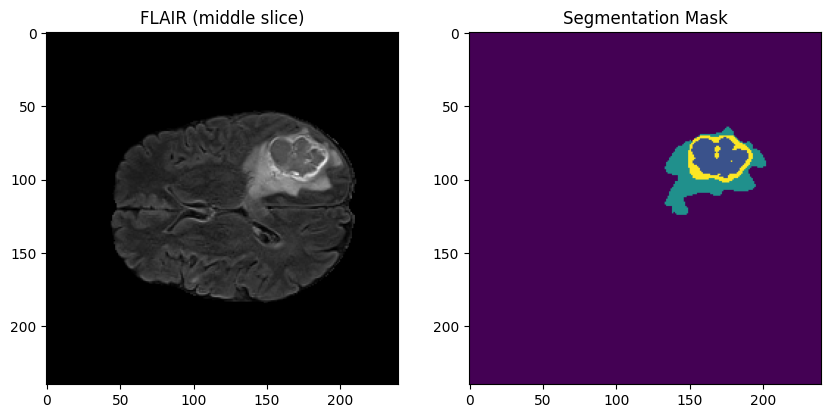

In [14]:
#load flair and seg. mask
flair_path = os.path.join(patient_path, f'{sample_patient}_flair.nii.gz')
seg_path = os.path.join(patient_path, f'{sample_patient}_seg.nii.gz')

flair = nib.load(flair_path).get_fdata()
seg = nib.load(seg_path).get_fdata()

mid_slice = flair.shape[2] // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(flair[:, :, mid_slice], cmap='gray')
axes[0].set_title('FLAIR (middle slice)')
axes[1].imshow(seg[:, :, mid_slice], cmap='viridis')
axes[1].set_title('Segmentation Mask')
plt.show()